In [124]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

import matplotlib.pyplot as plt

from pathlib import Path

In [125]:
# -------------------------
# INPUT and CLEANING
# -------------------------

BASE_DIR = Path.cwd().parent
PROCESSED_PATH = BASE_DIR / "data" / "processed"

df_us = pd.read_csv(PROCESSED_PATH / "usa_state_dataset.csv")
df_hhs = pd.read_csv(PROCESSED_PATH / "hhs_dataset.csv")
df_it = pd.read_csv(PROCESSED_PATH / "italy_dataset.csv")

df_it = df_it.sort_values(
    by=['year_week', 'region', 'age_class'],
    ascending=True
)
VALID_AGE_CLASSES = {"total", "0-4", "5-14", "15-64", "65+"}
df_it = df_it[df_it["age_class"].isin(VALID_AGE_CLASSES)].copy()

OUTPUT_PATH = BASE_DIR / "outputs" / "step1"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [126]:
# -------------------------
# HHS RSV incidence rate creation 
# -------------------------

df_hhs = df_hhs.copy()

cols_num = ["RSV Detections", "HHS_population"]
df_hhs[cols_num] = df_hhs[cols_num].apply(
    pd.to_numeric, errors="coerce"
)

df_hhs["rsv_inc_hhs_per_1000"] = (
    df_hhs["RSV Detections"]
    / df_hhs["HHS_population"]
) * 1000

weighted_sum = (
    df_hhs["rsv_inc_hhs_per_1000"] *
    df_hhs["HHS_population"]
)

df_hhs["rsv_inc_hhs_nat_per_1000"] = (
    weighted_sum
    .groupby([df_hhs["flu_season"], df_hhs["week"]])
    .transform("sum")
    /
    df_hhs.groupby(["flu_season", "week"])["HHS_population"]
          .transform("sum")
)

print(
    "HHS RSV incidence available:",
    df_hhs["rsv_inc_hhs_nat_per_1000"].notna().sum()
)


HHS RSV incidence available: 2780


In [127]:
# =========================
# CONFIGURATION Italian Dataset
# =========================
REGION = "Lombardia"
AGE_TOTAL = "total"
REG_ITALY = "Italy"

COL_TEMP = "temp_mean_C"
COL_DEW_CANDIDATES = ["dewpoint_mean_C", "dew_point_mean_C"]
COL_RH   = "RH_mean"
COL_FLU_CASES = "cases_influenza"
COL_POP = "population"
COL_WEEK = "week"
COL_SEASON = "flu_season"

COL_ARI_EST_ITA = "ARI Incidence per 1000 assisted_national_general_data"
COL_RSV_PCT_ITA = "Positive sample percentage RSV_national_general_data"

join_keys = [COL_SEASON, COL_WEEK]

# =========================
# UTILITY FUNCTIONS
# =========================
def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).replace("nan", np.nan),
        errors="coerce"
    )

def first_non_na(x: pd.Series):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

def pick_dew_col(df: pd.DataFrame) -> str | None:
    for c in COL_DEW_CANDIDATES:
        if c in df.columns:
            return c
    return None


In [128]:
# =========================
# PREPROCESS
# =========================
df_it = df_it.copy()

VALID_AGE_CLASSES = {"total", "0-4", "5-14", "15-64", "65+"}
df_it = df_it[df_it["age_class"].isin(VALID_AGE_CLASSES)].copy()

COL_DEW = pick_dew_col(df_it)

num_candidates = [COL_TEMP, COL_RH, COL_FLU_CASES, COL_POP, COL_WEEK, COL_ARI_EST_ITA, COL_RSV_PCT_ITA]
if COL_DEW is not None:
    num_candidates.append(COL_DEW)

for c in num_candidates:
    if c in df_it.columns:
        df_it[c] = to_num(df_it[c])

df_it["season_start_year"] = pd.to_numeric(df_it[COL_SEASON].astype(str).str.slice(0, 4), errors="coerce")
df_it = df_it[df_it["season_start_year"] >= 2017].copy()

# =========================
# LOMBARDY TOTAL CASES
# =========================
df_lomb = df_it[(df_it["region"] == REGION) & (df_it["age_class"] == AGE_TOTAL)].copy()

agg_lomb = {
    "pop_lomb": (COL_POP, "sum"),
    "flu_cases_lomb": (COL_FLU_CASES, "sum"),
}
if COL_TEMP in df_lomb.columns:
    agg_lomb["temp"] = (COL_TEMP, "mean")
if COL_DEW is not None and COL_DEW in df_lomb.columns:
    agg_lomb["dew"] = (COL_DEW, "mean")
if COL_RH in df_lomb.columns:
    agg_lomb["rh"] = (COL_RH, "mean")

lomb = df_lomb.groupby(join_keys, as_index=False).agg(**agg_lomb)
# =========================
# ITALY TOTAL CASES
# =========================
df_ita = df_it[(df_it["region"] == REG_ITALY) & (df_it["age_class"] == AGE_TOTAL)].copy()

ita = (
    df_ita.groupby(join_keys, as_index=False)
          .agg(
              pop_ita=(COL_POP, "sum"),
              flu_cases_ita=(COL_FLU_CASES, "sum"),
              ari_est_ita=(COL_ARI_EST_ITA, "mean"),
              rsv_pct_ita=(COL_RSV_PCT_ITA, "mean"),
          )
)

# =========================
# MERGE LOMBARDY-ITALY
# =========================
wk = lomb.merge(ita, on=join_keys, how="left")

df_hhs_nat = (
    df_hhs[[COL_SEASON, COL_WEEK, "rsv_inc_hhs_nat_per_1000"]]
    .drop_duplicates()
)

wk = wk.merge(
    df_hhs_nat,
    on=[COL_SEASON, COL_WEEK],
    how="left"
)

wk = wk.sort_values(join_keys).reset_index(drop=True)

wk["season_start_year"] = pd.to_numeric(
    wk[COL_SEASON].astype(str).str.slice(0, 4),
    errors="coerce"
)


# =========================
# ARI AND RSV POSITIVITY 
# =========================
wk["ari_est_ita"] = (
    wk.groupby(COL_SEASON)["ari_est_ita"]
      .transform(lambda s: s.interpolate(limit_direction="both"))
      .ffill()
)

wk["rsv_pct_ita"] = (
    wk.groupby(COL_SEASON)["rsv_pct_ita"]
      .transform(lambda s: s.interpolate(limit_direction="both"))
      .ffill()
)

# =========================
# FEATURE ENGINEERING
# =========================
wk["flu_inc_lomb_per_1000"] = (
    wk["flu_cases_lomb"] / wk["pop_lomb"]
) * 1000

wk["flu_inc_ita_per_1000"] = (
    wk["flu_cases_ita"] / wk["pop_ita"]
) * 1000

wk["flu_ratio"] = (
    wk["flu_inc_lomb_per_1000"] / wk["flu_inc_ita_per_1000"]
)

wk.loc[~np.isfinite(wk["flu_ratio"]), "flu_ratio"] = np.nan

wk["flu_ratio_smooth"] = (
    wk.groupby(COL_SEASON)["flu_ratio"]
      .transform(lambda s: s.rolling(window=3, min_periods=1).median())
)

wk["flu_ratio_smooth"] = wk["flu_ratio_smooth"].fillna(1.0)

wk["season_week"] = np.where(
    wk[COL_WEEK] >= 40,
    wk[COL_WEEK] - 39,
    wk[COL_WEEK] + 13
)


# =========================
# TARGET RSV LOMBARDY
# =========================

season_mean_rsv = (
    wk.groupby(COL_SEASON)["rsv_inc_hhs_nat_per_1000"]
      .transform(lambda s: s.mean(skipna=True))
)
wk["rsv_intensity"] = (
    wk["ari_est_ita"] *
    wk["rsv_pct_ita"] / 100
)

scale = (
    wk.groupby(COL_SEASON)["rsv_inc_hhs_nat_per_1000"]
      .transform("mean")
)

wk["rsv_intensity"] *= scale / scale.mean()

wk["rsv_intensity"] = wk["rsv_intensity"].replace([np.inf, -np.inf], np.nan)
wk["rsv_intensity"] = wk["rsv_intensity"].fillna(1.0)


wk["ari_cases_ita"] = wk["ari_est_ita"] * wk["pop_ita"] / 1000
wk["ari_est_lomb"] = wk["ari_cases_ita"] * (wk["pop_lomb"] / wk["pop_ita"])

wk["rsv_est_lomb"] = wk["ari_est_lomb"] * wk["rsv_intensity"]

wk["rsv_inc_per_1000_lomb"] = (
    wk["rsv_est_lomb"] / wk["pop_lomb"]
) * 1000

for lag in [1, 2, 3, 4]:
    wk[f"flu_lomb_lag{lag}"] = (
        wk.groupby(COL_SEASON)["flu_inc_lomb_per_1000"].shift(lag)
    )

    wk[f"flu_ita_lag{lag}"] = (
        wk.groupby(COL_SEASON)["flu_inc_ita_per_1000"].shift(lag)
    )

# =========================
# TRAINING SET PREPARATION
# =========================
feature_cols_num = [
    "season_week",
    "flu_inc_lomb_per_1000",
    "flu_inc_ita_per_1000",
    "flu_ratio_smooth",
    "rsv_inc_hhs_nat_per_1000",

    "flu_lomb_lag1",
    "flu_lomb_lag2",
    "flu_lomb_lag3",
    "flu_lomb_lag4",

    "flu_ita_lag1",
    "flu_ita_lag2",
    "flu_ita_lag3",
    "flu_ita_lag4"
]


if "temp" in wk.columns: feature_cols_num.append("temp")
if "dew"  in wk.columns: feature_cols_num.append("dew")
if "rh"   in wk.columns: feature_cols_num.append("rh")

feature_cols_cat = [COL_SEASON]

TARGET_COL = "rsv_inc_per_1000_lomb"

TRAIN_FROM_YEAR = 2018

train_df = (
    wk[wk["season_start_year"] >= TRAIN_FROM_YEAR]
    .dropna(subset=[TARGET_COL])
    .copy()
)


print("\nFINAL TRAINING SET :")
print("Row with available training set:", len(train_df))

if len(train_df) < 10:
    print("Warning: few data in training set")

X_train = train_df[feature_cols_num + feature_cols_cat]
y_train = np.log1p(train_df[TARGET_COL])

# =========================
# MODEL
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), feature_cols_num),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), feature_cols_cat),
    ],
    remainder="drop"
)

model = HistGradientBoostingRegressor(
    loss="poisson",
    max_depth=4,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)


# =========================
# PREDICTIONS
# =========================
X_all = wk[feature_cols_num + feature_cols_cat]

wk["rsv_inc_per_1000_lomb_model"] = np.expm1(pipe.predict(X_all))

wk["rsv_inc_per_1000_lomb_model"] = (
    wk["rsv_inc_per_1000_lomb_model"].clip(lower=0)
)


# =========================
# FINAL OUTPUT
# =========================
feature_cols_num = [
    "season_week",
    "flu_inc_lomb_per_1000",
    "flu_inc_ita_per_1000",
    "flu_ratio_smooth",
    "rsv_inc_hhs_nat_per_1000",

    "flu_lomb_lag1",
    "flu_lomb_lag2",
    "flu_lomb_lag3",
    "flu_lomb_lag4",

    "flu_ita_lag1",
    "flu_ita_lag2",
    "flu_ita_lag3",
    "flu_ita_lag4"
]

out = wk[feature_cols_num + [COL_WEEK]].copy()

out = out.loc[
    (out[COL_WEEK] >= 40) | (out[COL_WEEK] <= 20)
].reset_index(drop=True)

out.head(30)


FINAL TRAINING SET :
Row with available training set: 193


,season_week,flu_inc_lomb_per_1000,flu_inc_ita_per_1000,flu_ratio_smooth,rsv_inc_hhs_nat_per_1000,flu_lomb_lag1,flu_lomb_lag2,flu_lomb_lag3,flu_lomb_lag4,flu_ita_lag1,flu_ita_lag2,flu_ita_lag3,flu_ita_lag4,week
0,14,0.187289,0.0,1.0,0.013921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,15,0.225949,0.0,1.0,0.013482,0.187289,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2
2,16,0.217536,0.0,1.0,0.013422,0.225949,0.187289,NaN,NaN,0.0,0.0,NaN,NaN,3
3,17,0.234862,0.0,1.0,0.014378,0.217536,0.225949,0.187289,NaN,0.0,0.0,0.0,NaN,4
4,18,0.204115,0.0,1.0,0.014321,0.234862,0.217536,0.225949,0.187289,0.0,0.0,0.0,0.0,5
5,19,0.176272,0.0,1.0,0.013361,0.204115,0.234862,0.217536,0.225949,0.0,0.0,0.0,0.0,6
6,20,0.115979,0.0,1.0,0.012256,0.176272,0.204115,0.234862,0.217536,0.0,0.0,0.0,0.0,7
7,21,0.093544,0.0,1.0,0.010077,0.115979,0.176272,0.204115,0.234862,0.0,0.0,0.0,0.0,8
8,22,0.071611,0.0,1.0,0.008588,0.093544,0.115979,0.176272,0.204115,0.0,0.0,0.0,0.0,9
9,23,0.059492,0.0,1.0,0.006711,0.071611,0.093544,0.115979,0.176272,0.0,0.0,0.0,0.0,10


In [129]:
# =========================
# AGE CLASS WEIGHT
# =========================

flu_age = (
    df_it[(df_it["region"] == REGION) & (df_it["age_class"] != "total")]
    .groupby(["flu_season", "week", "age_class"], as_index=False)
    .agg(
        flu_cases=("cases_influenza", "sum")
    )
)

flu_age["w_age"] = (
    flu_age["flu_cases"]
    / flu_age.groupby(["flu_season", "week"])["flu_cases"].transform("sum")
)

w_age_week = flu_age[["flu_season", "week", "age_class", "w_age"]]


In [ ]:
TOT_COL = "rsv_inc_per_1000_lomb_model"

ages = ["0-4", "5-14", "15-64", "65+"]

wk_tot = wk[[COL_SEASON, COL_WEEK, TOT_COL]].copy()

tmpl = wk_tot.merge(
    pd.DataFrame({"age_class": ages}),
    how="cross"
)

tmpl = tmpl.merge(
    w_age_week,
    on=[COL_SEASON, COL_WEEK, "age_class"],
    how="left"
)

tmpl["w_age"] = tmpl["w_age"].fillna(1.0 / len(ages))

tmpl["rsv_inc_per_1000_lomb_by_age"] = tmpl[TOT_COL] * tmpl["w_age"]

rsv65_raw = tmpl.loc[tmpl["age_class"] == "65+", "rsv_inc_per_1000_lomb_by_age"].copy()

prev_peak = 0.09
dur_days_mid = 13
target_peak_per_1000 = (prev_peak * 7 / dur_days_mid) * 1000  

raw_peak = float(rsv65_raw.max())
k65 = target_peak_per_1000 / raw_peak if raw_peak > 0 else 1.0

tmpl.loc[tmpl["age_class"] == "65+", "rsv_inc_per_1000_lomb_65_cal"] = (
    tmpl.loc[tmpl["age_class"] == "65+", "rsv_inc_per_1000_lomb_by_age"] * k65
)
rsv65_series = tmpl.loc[tmpl["age_class"] == "65+", [COL_SEASON, COL_WEEK, "rsv_inc_per_1000_lomb_65_cal"]]

In [131]:
# =========================
# FINAL DATASET
# =========================

df_final = (
    df_it[
        (df_it["region"] == "Lombardia") &
        (df_it["age_class"] == "65+")
    ]
    .copy()
)
df_final["season_start_year"] = pd.to_numeric(
    df_final["flu_season"].str.slice(0, 4),
    errors="coerce"
)

df_final = df_final[df_final["season_start_year"] >= 2018].copy()

rsv65 = tmpl.loc[
    tmpl["age_class"] == "65+",
    ["flu_season", "week", "age_class", "rsv_inc_per_1000_lomb_65_cal"]
].copy()

df_final = df_final.merge(
    rsv65,
    on=["flu_season", "week", "age_class"],
    how="left"
)

df_final = df_final.drop(columns="season_start_year")
df_final = df_final.rename(
    columns={
        "rsv_inc_per_1000_lomb_65_cal":
        "rsv_inc_65_baseline_per_1000"
    }
)
df_final["rsv_cases_65_baseline"] = (
    df_final["rsv_inc_65_baseline_per_1000"] / 1000
) * df_final["population"]

print("Final dataset shape:", df_final.shape)
df_final.head()


Final dataset shape: (194, 36)


,region,flu_season,week,age_class,year_week,cases_influenza,incidence_influenza,vaccination_ratio_influenza,temp_mean_C,dewpoint_mean_C,...,Sars-Cov-2 Positive sample_national_general_data,RSV Positive sample_national_general_data,ARI Serious cases and complication_national_general_data,Total Cases_national_data,Incidence Rate_national_data,Total Assisted People_national_data,Superficie,density,rsv_inc_65_baseline_per_1000,rsv_cases_65_baseline
0,Lombardia,2018-2019,43,65+,2018-43,28.0,1.26,NaN,15.38,10.56,...,NaN,NaN,NaN,NaN,NaN,NaN,23862.87,94.012497,1.706463,3828.291668
1,Lombardia,2018-2019,44,65+,2018-44,25.0,0.95,NaN,13.72,10.91,...,NaN,NaN,NaN,NaN,NaN,NaN,23862.87,94.012497,2.754725,6179.972256
2,Lombardia,2018-2019,45,65+,2018-45,34.0,1.59,NaN,14.56,13.04,...,NaN,NaN,NaN,NaN,NaN,NaN,23862.87,94.012497,2.196696,4928.084878
3,Lombardia,2018-2019,46,65+,2018-46,25.0,0.95,NaN,11.39,7.77,...,NaN,NaN,NaN,NaN,NaN,NaN,23862.87,94.012497,1.918761,4304.564694
4,Lombardia,2018-2019,47,65+,2018-47,38.0,1.55,NaN,6.92,5.18,...,NaN,NaN,NaN,NaN,NaN,NaN,23862.87,94.012497,3.768724,8454.785213


In [113]:
df_final.drop(columns=['ARI Incidence per 1000 assisted_national_general_data', 'Total ARI cases_national_general_data', 'Total estimated cases_national_general_data', 'Positive sample percentage Influenza_national_general_data', 'Positive sample percentage Sars-Cov-2_national_general_data', 'Positive sample percentage RSV_national_general_data', 'Positive sample Influenza_national_general_data', 'Positive sample Sars-Cov-2_national_general_data', 'Positive sample RSV_national_general_data', 'ARI Hospedalization_national_general_data', 'Positive rate in influenza in flusso ospedaliero_national_general_data', 'Positive rate in Sars-Cov-2 in flusso ospedaliero_national_general_data', 'Positive rate in RSV in flusso ospedaliero_national_general_data', 'Influenza Positive sample_national_general_data', 'Sars-Cov-2 Positive sample_national_general_data', 'RSV Positive sample_national_general_data', 'ARI Serious cases and complication_national_general_data', 'Total Cases_national_data', 'Incidence Rate_national_data', 'Total Assisted People_national_data'], inplace=True)

In [115]:
df_final.to_excel(
    OUTPUT_PATH / "rsv_lombardia.xlsx",
    index=False
)

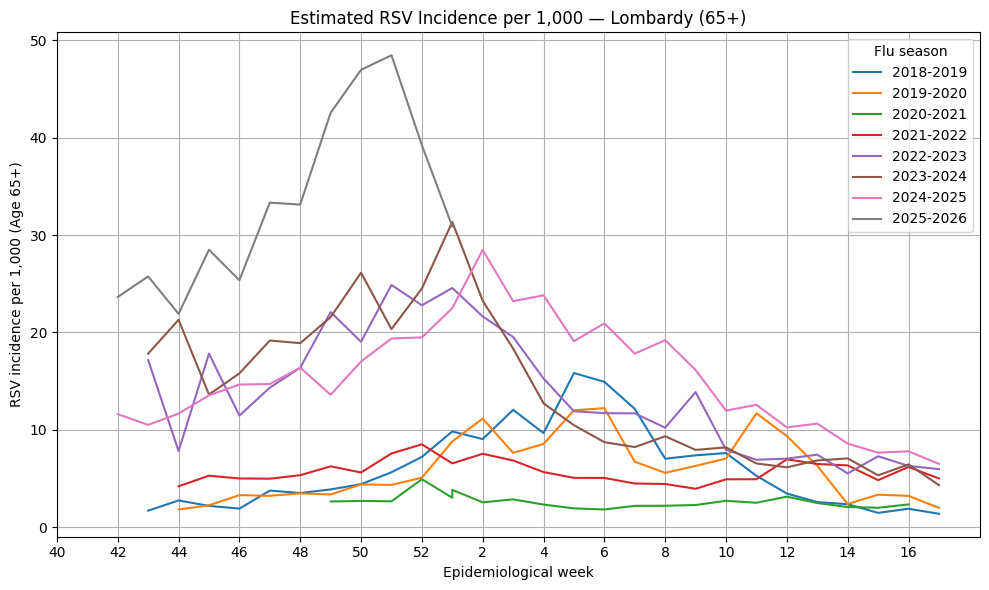

In [ ]:
# =========================
# PLOT
# =========================


COL_RSV65 = "rsv_inc_65_baseline_per_1000"

df_final["season_week"] = np.where(
    df_final[COL_WEEK] >= 40,
    df_final[COL_WEEK] - 39,
    df_final[COL_WEEK] + 13
)

df_final = df_final[
    (df_final[COL_WEEK] >= 40) | (df_final[COL_WEEK] <= 17)
].copy()

df_final = df_final.sort_values([COL_SEASON, "season_week"])

season_weeks = list(range(40, 53)) + list(range(1, 18))
season_index = np.arange(1, len(season_weeks) + 1)


plt.figure(figsize=(10, 6))

for season, d in df_final.groupby(COL_SEASON):
    plt.plot(
        d["season_week"],
        d[COL_RSV65],
        label=season
    )

plt.xlabel("Epidemiological week")
plt.ylabel("RSV incidence per 1,000 (Age 65+)")
plt.title("Estimated RSV Incidence per 1,000 — Lombardy (65+)")
plt.grid(True)


plt.xticks(
    ticks=season_index[::2],           
    labels=season_weeks[::2]
)

plt.legend(title="Flu season")

plt.tight_layout()
OUT_PATH = OUTPUT_PATH / "rsv_lombardy_65plus_incidence.png"
plt.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
